In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve
import numpy as np

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *
from Utilities.Plot_functions import *

---

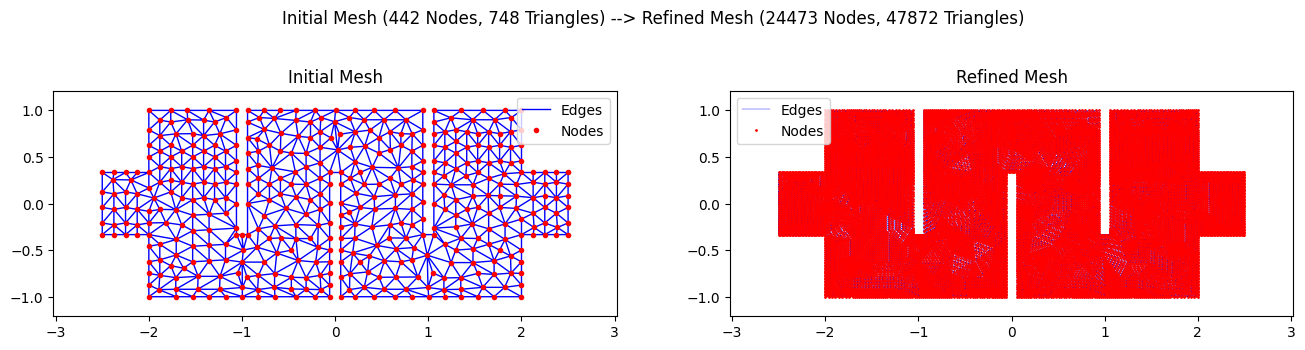

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=True,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

### Viscosity Snapshots

--- GLOBAL STATISTICS ---
Total Snapshots:      100
Elements per Mesh:    191488
Absolute Min ( >0? ): 10.242768
Absolute Max:         199.898669
Global Mean:          104.964117

--- SPATIAL VARIABILITY ---
Highest variability at element 97408 (Std: 54.903198)
Lowest variability is 29.664079

--- INTRINSIC DIMENSIONALITY ---
Modes needed to capture 99.9% of viscosity variance: 5


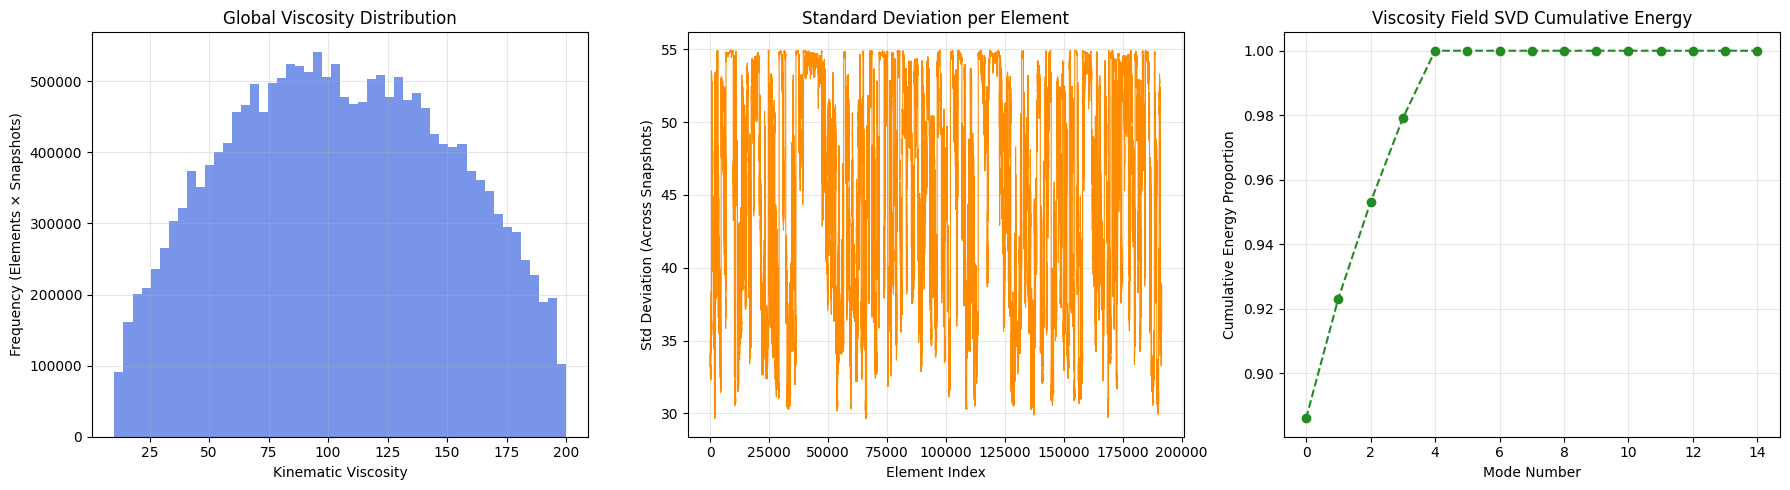

In [4]:
# 1. Load Data
npz_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
with np.load(npz_path) as data:
    v_t = data['v_t_snapshots']  # Shape expected: (n_snapshots, n_elements)

n_snapshots, n_elements = v_t.shape

# ---------------------------------------------------------
# 2. Global Statistics (Sanity Checks)
# ---------------------------------------------------------
print("--- GLOBAL STATISTICS ---")
print(f"Total Snapshots:      {n_snapshots}")
print(f"Elements per Mesh:    {n_elements}")
print(f"Absolute Min ( >0? ): {np.min(v_t):.6f}")
print(f"Absolute Max:         {np.max(v_t):.6f}")
print(f"Global Mean:          {np.mean(v_t):.6f}")

# ---------------------------------------------------------
# 3. Spatial Variance (Where does the field change most?)
# ---------------------------------------------------------
element_std = np.std(v_t, axis=0)
max_var_elem = np.argmax(element_std)

print("\n--- SPATIAL VARIABILITY ---")
print(f"Highest variability at element {max_var_elem} (Std: {np.max(element_std):.6f})")
print(f"Lowest variability is {np.min(element_std):.6f}")

# ---------------------------------------------------------
# 4. Dimensionality / Complexity (ROM prep)
# ---------------------------------------------------------
# Performing SVD on the parameter field reveals its mathematical rank.
# Because your field is built using 5 knots, the rank should be low.
_, S, _ = np.linalg.svd(v_t, full_matrices=False)
energy = np.cumsum(S**2) / np.sum(S**2)
modes_99 = np.searchsorted(energy, 0.999) + 1

print("\n--- INTRINSIC DIMENSIONALITY ---")
print(f"Modes needed to capture 99.9% of viscosity variance: {modes_99}")

# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Overall Distribution
axes[0].hist(v_t.flatten(), bins=50, color='royalblue', alpha=0.7)
axes[0].set_title("Global Viscosity Distribution")
axes[0].set_xlabel("Kinematic Viscosity")
axes[0].set_ylabel("Frequency (Elements × Snapshots)")
axes[0].grid(alpha=0.3)

# Plot B: Spatial Variability
axes[1].plot(element_std, color='darkorange', linewidth=0.8)
axes[1].set_title("Standard Deviation per Element")
axes[1].set_xlabel("Element Index")
axes[1].set_ylabel("Std Deviation (Across Snapshots)")
axes[1].grid(alpha=0.3)

# Plot C: Singular Value Decay
axes[2].plot(energy[:15], marker='o', color='forestgreen', linestyle='--')
axes[2].set_title("Viscosity Field SVD Cumulative Energy")
axes[2].set_xlabel("Mode Number")
axes[2].set_ylabel("Cumulative Energy Proportion")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

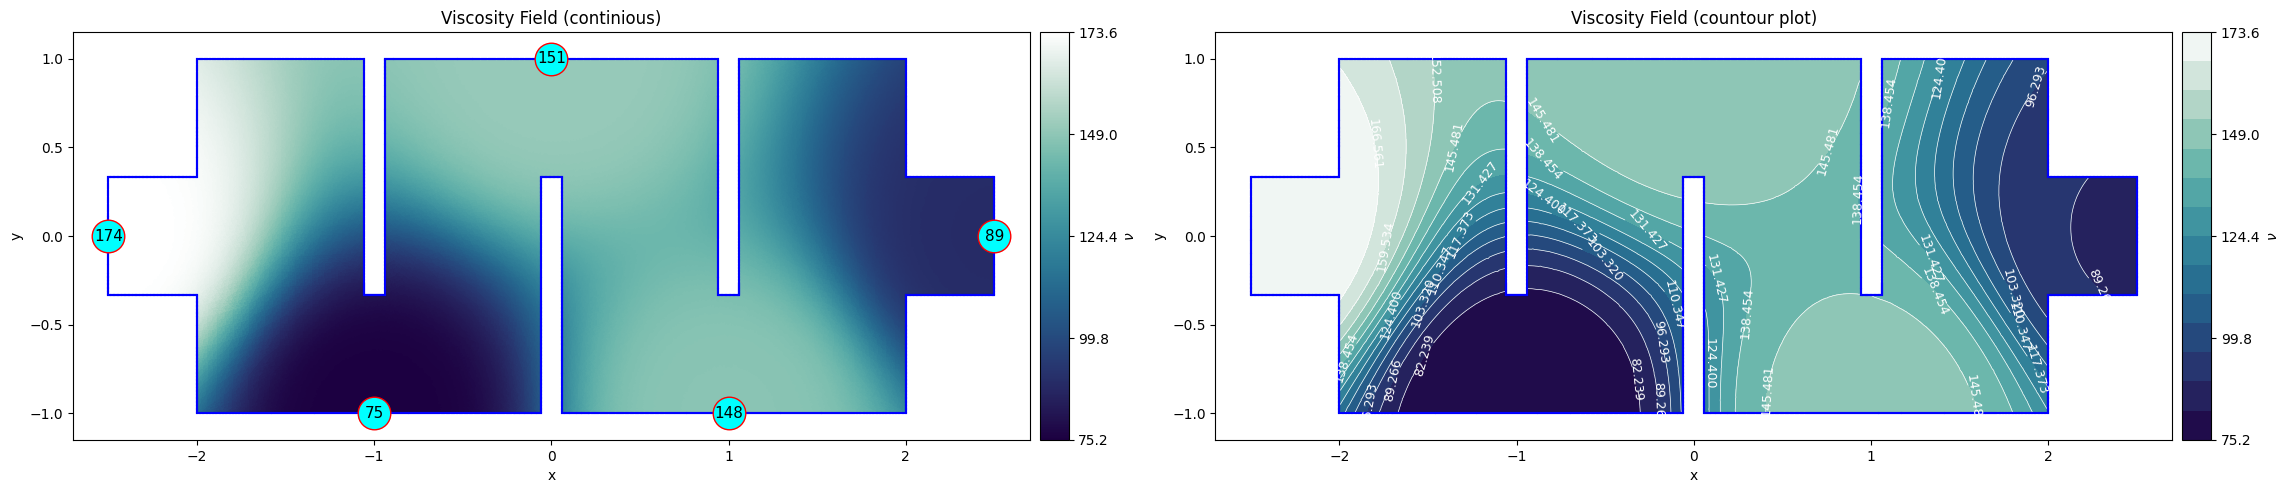

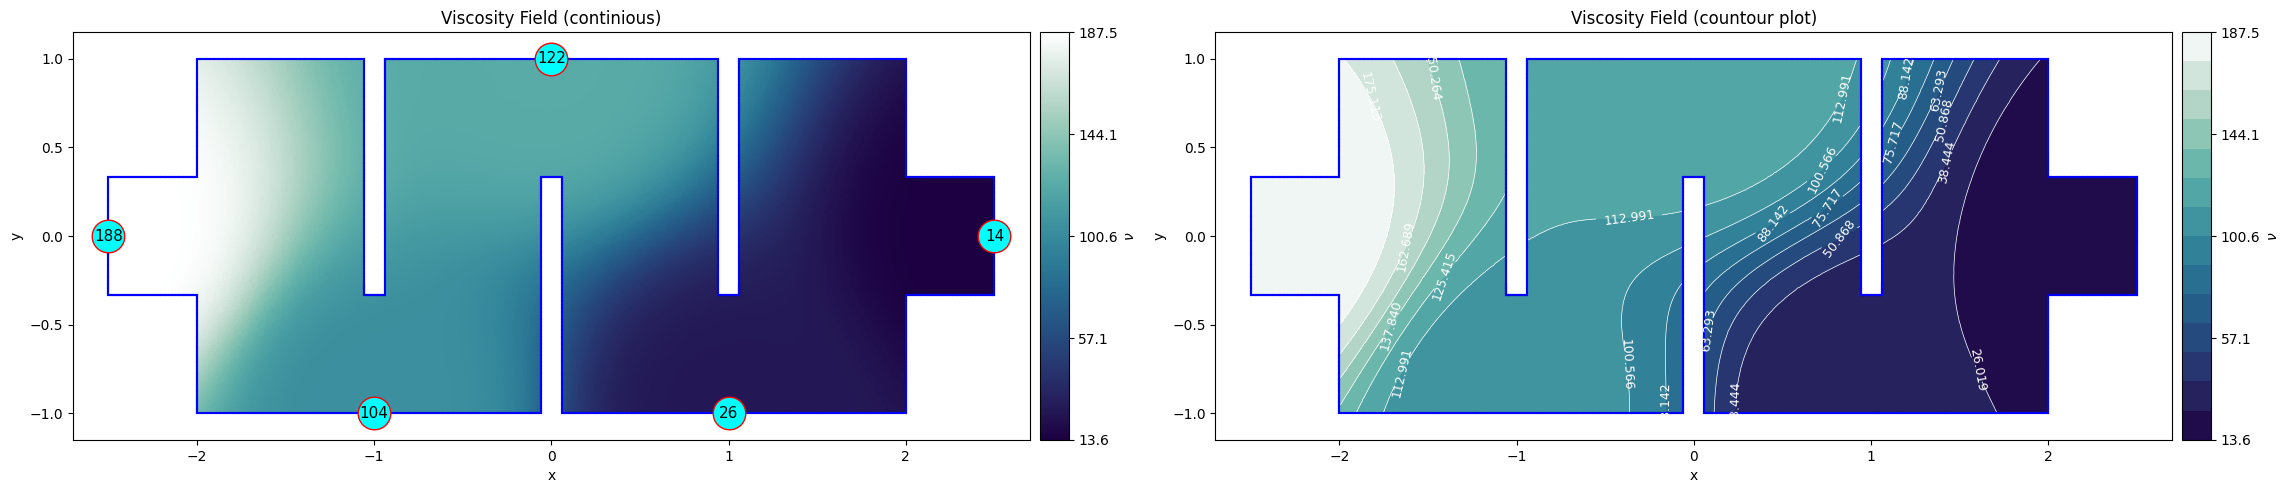

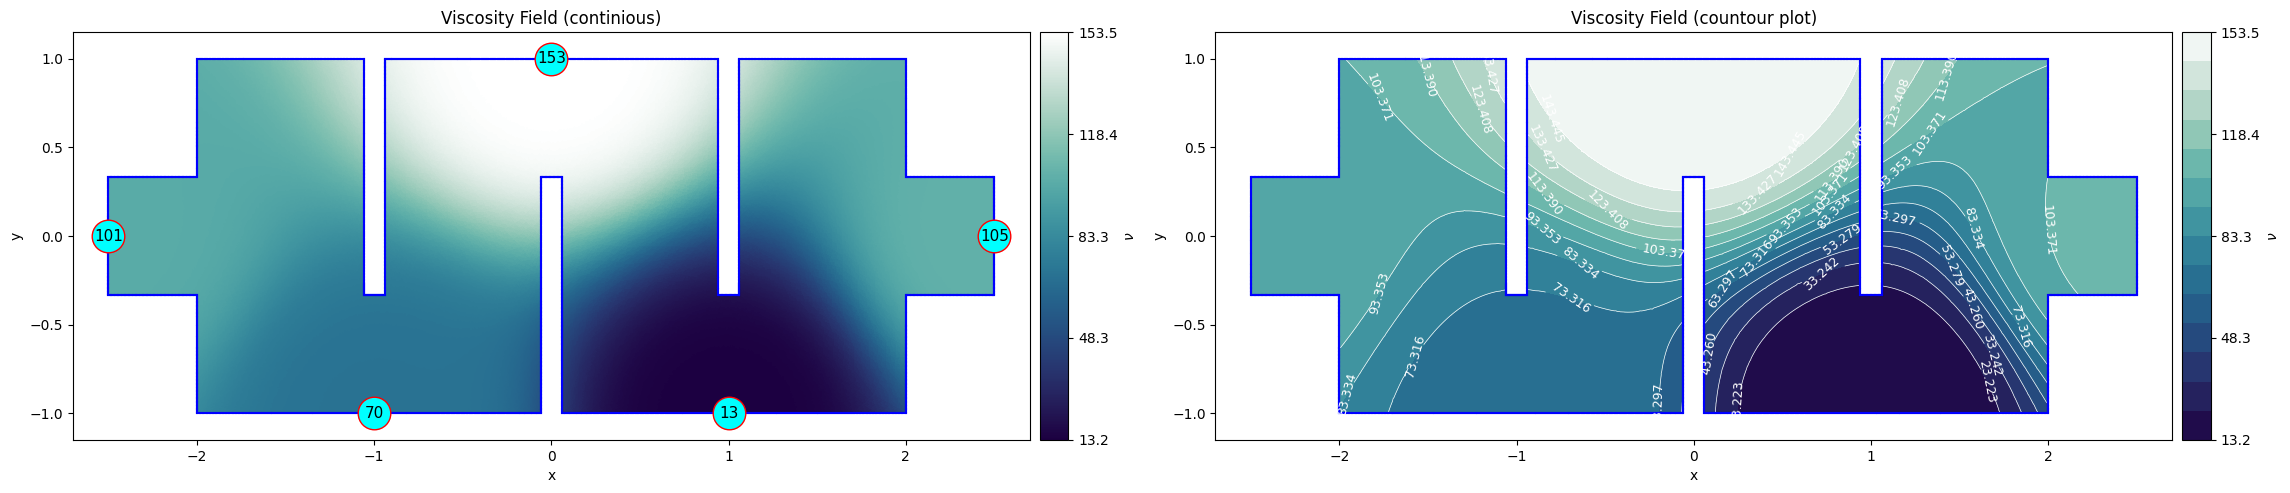

In [5]:
npz_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
data = np.load(npz_path)

p_fine = data['p_fine']
t_fine = data['t_fine']
e_fine = data['e_fine']
knots  = data['knots']

for snapshot_idx in [3, 7, 9]:
    v_t_snapshot = data['v_t_snapshots'][snapshot_idx]
    params_snapshot = data['parameters'][snapshot_idx]

    nu_KNOTS = {
        'pts': knots,
        'vals': params_snapshot
    }

    plot_viscosity(p_fine, t_fine, e_fine, v_t_snapshot, nu_KNOTS,
                n_levels=15,
                figsize=(23, 10),
                savetype='png')

data.close()


---

### Solution Snapshots

In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# 1. Environment & Path Resolution
# ──────────────────────────────────────────────────────────────────────────────
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
fem_dir = os.path.dirname(script_dir) if 'Demonstrations' in script_dir or 'Reduced_Order_Modeling' in script_dir else script_dir

npz_path = os.path.join(fem_dir, 'Reduced_Order_Modeling', 'Data', 'stokes_solution_snapshots.npz')

# ──────────────────────────────────────────────────────────────────────────────
# 2. Load the Data
# ──────────────────────────────────────────────────────────────────────────────
print("Loading snapshot database...")
with np.load(npz_path) as data:
    ux = data['ux_snapshots']
    uy = data['uy_snapshots']
    p  = data['p_snapshots']

num_snapshots, Nv = ux.shape
_, Np = p.shape

# Calculate Velocity Magnitude field for all snapshots
U_mag = np.sqrt(ux**2 + uy**2)

# ──────────────────────────────────────────────────────────────────────────────
# 3. Global Statistics & Spatial Variance
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print(" GLOBAL FIELD STATISTICS")
print("=" * 50)
print(f" Total Snapshots:     {num_snapshots}")
print("-" * 50)
print(f" Velocity Mag Min:    {np.min(U_mag):.6f}")
print(f" Velocity Mag Max:    {np.max(U_mag):.6f}")
print(f" Velocity Mag Mean:   {np.mean(U_mag):.6f}")
print("-" * 50)
print(f" Pressure Min:        {np.min(p):.2f}")
print(f" Pressure Max:        {np.max(p):.2f}")
print(f" Pressure Mean:       {np.mean(p):.2f}")
print("=" * 50)

Loading snapshot database...

 GLOBAL FIELD STATISTICS
 Total Snapshots:     100
--------------------------------------------------
 Velocity Mag Min:    0.000000
 Velocity Mag Max:    1.605584
 Velocity Mag Mean:   0.565803
--------------------------------------------------
 Pressure Min:        -60451.14
 Pressure Max:        272753.39
 Pressure Mean:       29020.09


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr # Assuming you are using cmasher for the ocean colormap

def plot_combined_solution(
    p_fine, t_fine, ux, uy,
    p_coarse, t_coarse, p_sol,
    p, t, e, nu_T, nu_KNOTS,
    levels: int = 90,
    n_levels_visc: int = 15,
    figsize: tuple = (24, 7),
    savetype: str = 'jpeg'
):
    """
    Plots Viscosity, Pressure, and Velocity Streamlines side-by-side in a 1x3 layout.
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)

    # -------------------------------------------------------------------------
    # COLUMN 1: VISCOSITY (Contour + Knots)
    # -------------------------------------------------------------------------
    triangulation_visc = tri.Triangulation(p[:, 0], p[:, 1], t[:, :3])
    
    nu_nodes = (np.bincount(t[:, :3].ravel(), weights=np.repeat(nu_T, 3), minlength=len(p)) / 
                np.maximum(np.bincount(t[:, :3].ravel(), minlength=len(p)), 1))
    
    visc_levels = np.linspace(np.min(nu_nodes), np.max(nu_nodes), n_levels_visc)

    cf1 = ax1.tricontourf(triangulation_visc, nu_nodes, levels=visc_levels, cmap=cmr.ocean)
    cs1 = ax1.tricontour(triangulation_visc,  nu_nodes, levels=visc_levels, colors='w', linewidths=0.5)
    ax1.clabel(cs1, inline=True, fontsize=9, fmt='%.3f')

    nu_pts = nu_KNOTS['pts']
    nu_vals = nu_KNOTS['vals']
    ax1.scatter(nu_pts[:, 0], nu_pts[:, 1], s=550, c='cyan', edgecolors='r', linewidths=1, zorder=3)
    
    for (x_coord, y_coord), val in zip(nu_pts, nu_vals):
        ax1.text(x_coord, y_coord, s=f"{val:.0f}", ha='center', va='center', fontsize=11, zorder=5)

    flag1_mask = (e[:, -1] == 1)
    boundary_edges = e[flag1_mask, :2].astype(int)
    for edge in boundary_edges:
        ax1.plot(p[edge, 0], p[edge, 1], color='b', linewidth=1.5)

    ax1.set_aspect('equal')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Viscosity Field')
    
    ax1.set_xlim(-2.70, 2.70)
    ax1.set_ylim(-1.15, 1.15)

    div1 = make_axes_locatable(ax1)
    cax1 = div1.append_axes("right", size="5%", pad=0.1)
    min_val1, max_val1 = np.min(nu_nodes), np.max(nu_nodes)
    ticks1 = np.linspace(min_val1, max_val1, 5)
    cb1 = fig.colorbar(cf1, cax=cax1, label=r'$\nu$', ticks=ticks1)
    cb1.ax.set_yticklabels([f'{val:.1f}' for val in ticks1])

    # -------------------------------------------------------------------------
    # COLUMN 2: PRESSURE
    # -------------------------------------------------------------------------
    triangulation_pres = tri.Triangulation(p_coarse[:, 0], p_coarse[:, 1], t_coarse[:, :3])
    cf2 = ax2.tricontourf(triangulation_pres, p_sol, levels=levels)

    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_aspect('equal')
    ax2.set_title('Pressure $\\mathbf{P}$')

    x_min, x_max = p_coarse[:, 0].min(), p_coarse[:, 0].max()
    x_margin = np.abs(x_max - x_min) * 0.03
    y_min, y_max = p_coarse[:, 1].min(), p_coarse[:, 1].max()
    y_margin = np.abs(y_max - y_min) * 0.03

    ax2.set_xlim([x_min - x_margin, x_max + x_margin])
    ax2.set_ylim([y_min - y_margin, y_max + y_margin])

    div2 = make_axes_locatable(ax2)
    cax2 = div2.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(cf2, cax=cax2, label='$\\mathbf{P}$')

    # -------------------------------------------------------------------------
    # COLUMN 3: VELOCITY STREAMLINES
    # -------------------------------------------------------------------------
    x_v = p_fine[:, 0]
    y_v = p_fine[:, 1]
    nx, ny = 300, 300
    xi = np.linspace(x_v.min(), x_v.max(), nx)
    yi = np.linspace(y_v.min(), y_v.max(), ny)
    X, Y = np.meshgrid(xi, yi)

    U = griddata((x_v, y_v), ux, (X, Y), method='cubic')
    V = griddata((x_v, y_v), uy, (X, Y), method='cubic')

    triang_v = tri.Triangulation(x_v, y_v, t_fine[:, :3])
    trifinder = triang_v.get_trifinder()
    
    geometry_mask = (trifinder(X, Y) == -1)
    U = np.ma.array(U, mask=geometry_mask)
    V = np.ma.array(V, mask=geometry_mask)
    speed = np.ma.sqrt(U**2 + V**2)

    cf3 = ax3.contourf(X, Y, speed, levels=levels, cmap='viridis')
    ax3.streamplot(X, Y, U, V, density=2.5, linewidth=1.2, arrowsize=1.2, color='white')

    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_aspect('equal')
    ax3.set_title("Streamlines of $\\vec{u}$")

    x_min_v, x_max_v = p_fine[:, 0].min(), p_fine[:, 0].max()
    x_margin_v = np.abs(x_max_v - x_min_v) * 0.03
    y_min_v, y_max_v = p_fine[:, 1].min(), p_fine[:, 1].max()
    y_margin_v = np.abs(y_max_v - y_min_v) * 0.03

    ax3.set_xlim([x_min_v - x_margin_v, x_max_v + x_margin_v])
    ax3.set_ylim([y_min_v - y_margin_v, y_max_v + y_margin_v])

    div3 = make_axes_locatable(ax3)
    cax3 = div3.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(cf3, cax=cax3, label='$\\|\\vec{u}\\|$')

    # -------------------------------------------------------------------------
    # FINAL RENDER
    # -------------------------------------------------------------------------
    plt.tight_layout()
    plt.savefig(f'Outputs/Combined_Solution.{savetype}', bbox_inches='tight')
    plt.show()

Displaying Pre-computed Snapshot: 0
Knot Viscosity Values: [101.98  36.22 101.36  52.3  129.49]


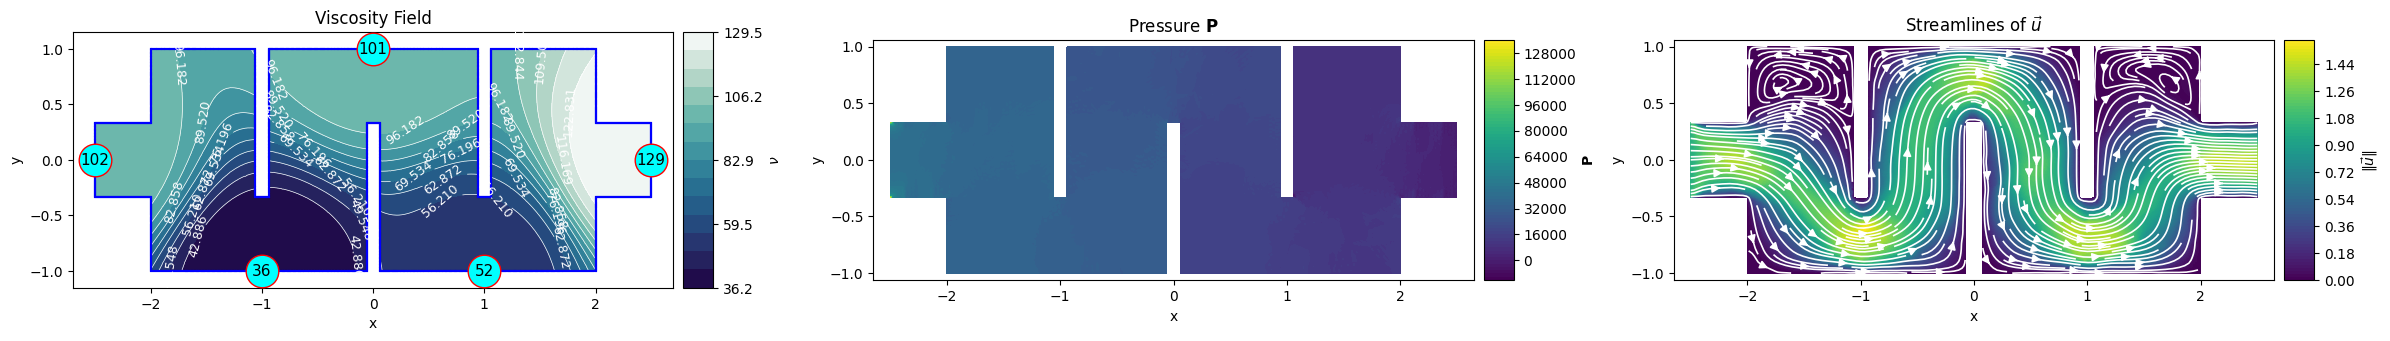

Displaying Pre-computed Snapshot: 1
Knot Viscosity Values: [112.49  48.23 125.38 181.36  27.42]


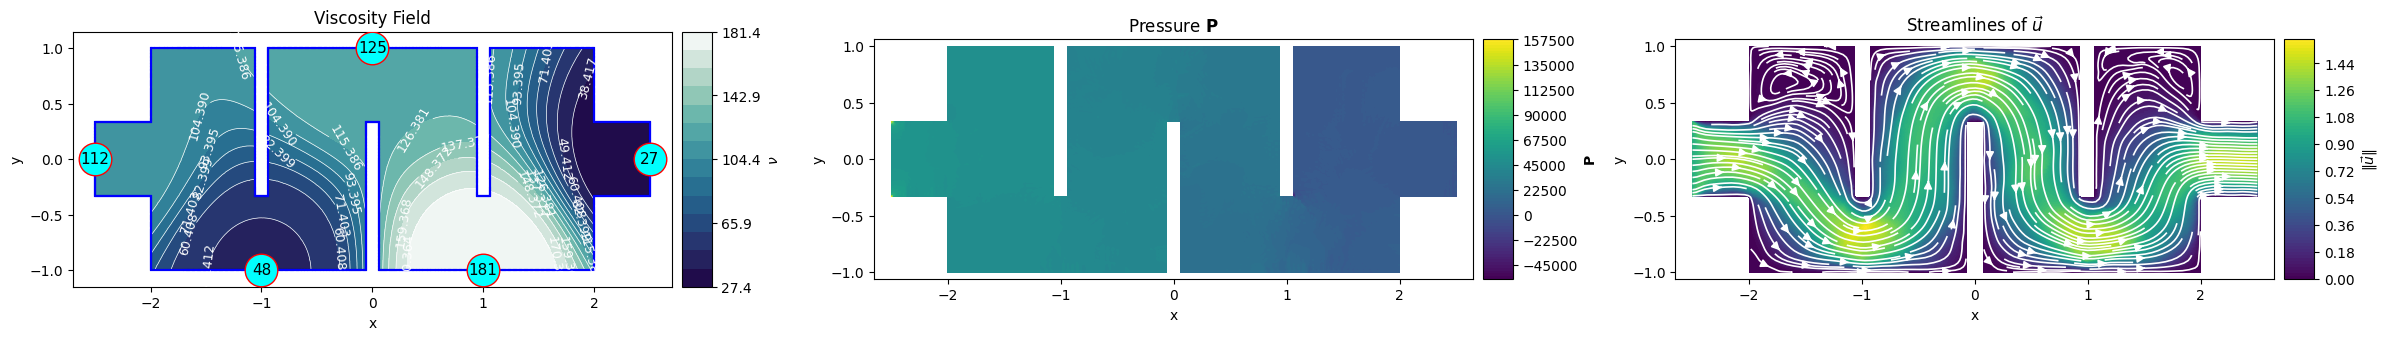

Displaying Pre-computed Snapshot: 2
Knot Viscosity Values: [ 77.35 190.54  58.72 145.93 115.13]


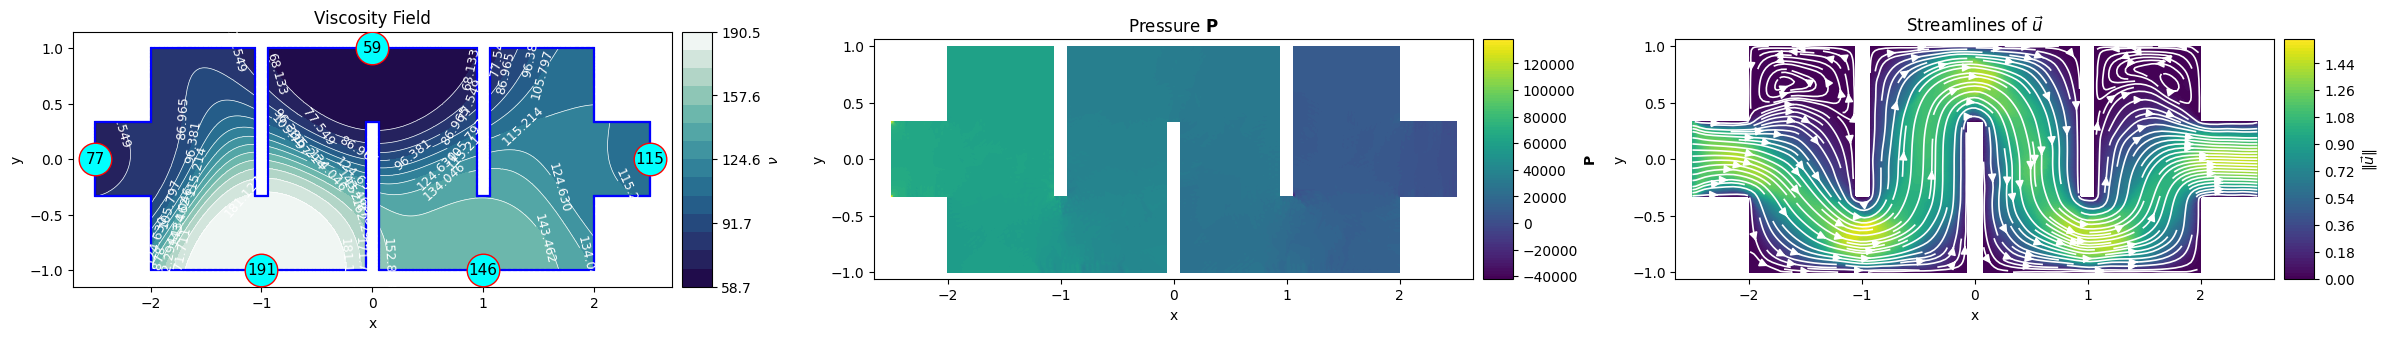

Displaying Pre-computed Snapshot: 3
Knot Viscosity Values: [173.59  75.21 150.52 147.9   89.01]


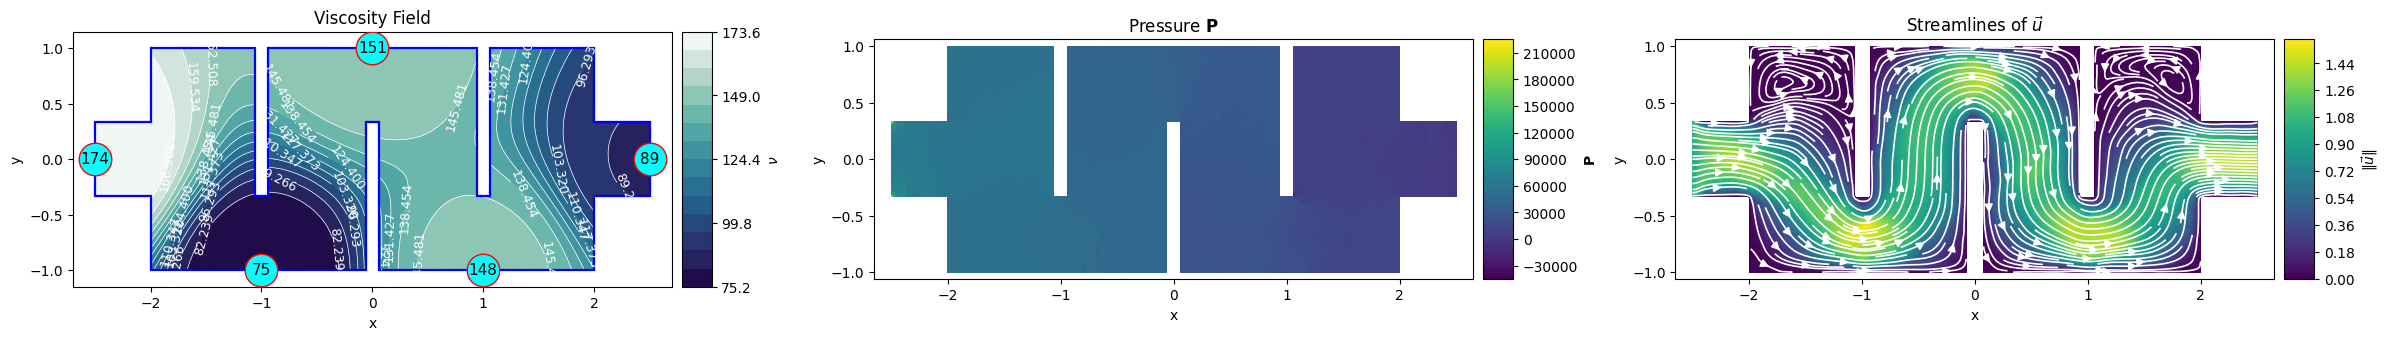

Displaying Pre-computed Snapshot: 4
Knot Viscosity Values: [ 85.59 165.5  159.56 118.94  32.82]


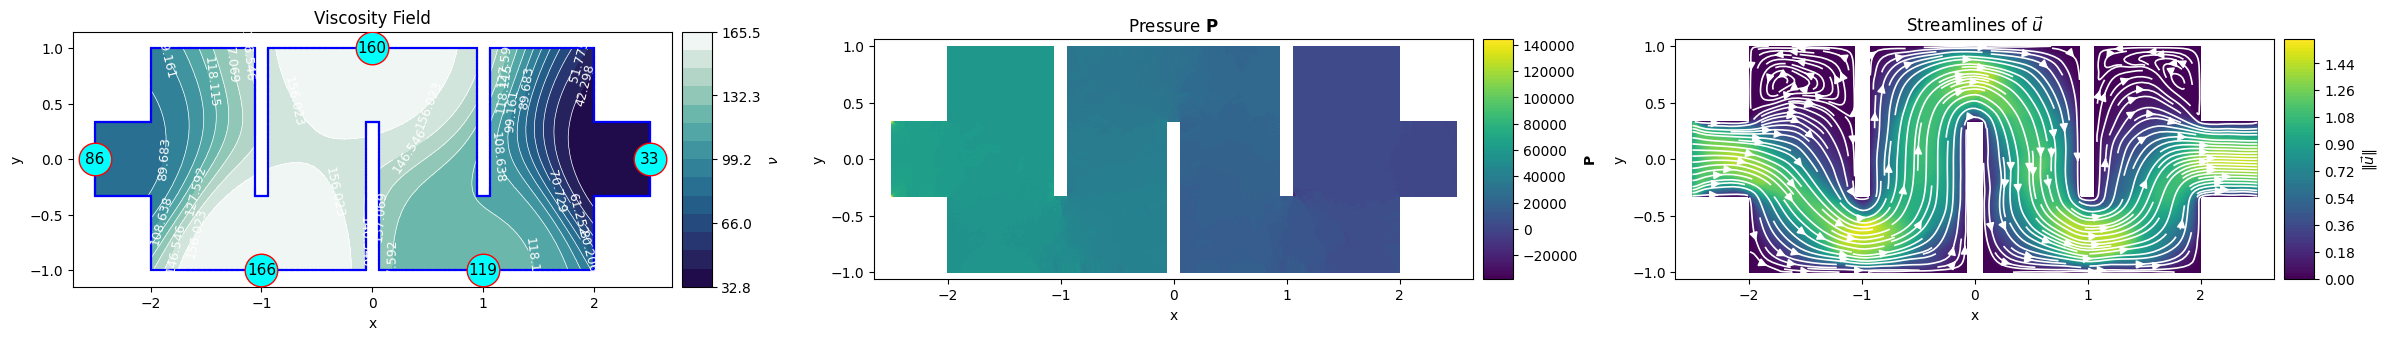

In [8]:
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
if os.path.basename(script_dir) == 'Demonstrations':
    os.chdir('..')
    script_dir = os.getcwd()

visc_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
sol_path  = os.path.join('Reduced_Order_Modeling', 'Data', 'stokes_solution_snapshots.npz')

with np.load(visc_path) as data_v:
    v_t_snapshots = data_v['v_t_snapshots']
    parameters    = data_v['parameters']
    knots         = data_v['knots']
    p_fine        = data_v['p_fine']
    t_fine        = data_v['t_fine']
    e_fine        = data_v['e_fine']
    # p_coarse = data_v['p_coarse'] 
    # t_coarse = data_v['t_coarse']

with np.load(sol_path) as data_s:
    ux_snapshots = data_s['ux_snapshots']
    uy_snapshots = data_s['uy_snapshots']
    p_snapshots  = data_s['p_snapshots']

snapshots_to_plot = range(5) 

for i in snapshots_to_plot:
    v_t_snap    = v_t_snapshots[i]  # The element-wise viscosity field
    params_snap = parameters[i]     # The 5 random knot values
    
    ux_snap     = ux_snapshots[i]   # X-velocity field
    uy_snap     = uy_snapshots[i]   # Y-velocity field
    p_snap      = p_snapshots[i]    # Pressure field
    
    # 2. Package the knots dictionary for the plotting function
    nu_KNOTS = {
        'pts': knots,
        'vals': params_snap
    }
    
    print(f"Displaying Pre-computed Snapshot: {i}")
    print(f"Knot Viscosity Values: {np.round(params_snap, 2)}")
    
    plot_combined_solution(
        p_fine=p_fine, t_fine=t_fine, ux=ux_snap, uy=uy_snap,
        p_coarse=p_coarse, t_coarse=t_coarse, p_sol=p_snap,
        p=p_fine, t=t_fine, e=e_fine, nu_T=v_t_snap, nu_KNOTS=nu_KNOTS,
        figsize=(24, 7), 
        savetype='png'
    )